In [2]:
# Install and import dependencies
%pip install optuna==3.2.0 xgboost==1.7.5 joblib

import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import SuccessiveHalvingPruner
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

print('Optuna version:', optuna.__version__)
print('XGBoost available:', XGB_AVAILABLE)

   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/70.9 MB ? eta -:--:--
   -----------------

In [3]:
# Notebook parameters
# Configure time_budget (secs) or n_trials. Use timeout OR n_trials. Default small budget for demo.
n_trials = 10
time_budget = 60*10  # 10 minutes demo budget; increase for full tuning
seed = 42
rf_study_name = 'optuna_rf_ap'
xgb_study_name = 'optuna_xgb_ap'
storage_url = None  # e.g. 'sqlite:///optuna.db' for resumable/distributed runs

print('n_trials:', n_trials, 'time_budget(s):', time_budget)

# Paths for outputs
os.makedirs('models', exist_ok=True)
results_json = 'models/optuna_tuning_results.json'
fig_dir = 'reports/figures'
os.makedirs(fig_dir, exist_ok=True)


n_trials: 10 time_budget(s): 600


In [4]:
# Load dataset and create reproducible splits
path = '../data/processed/fraud_data_features.csv'
if not os.path.exists(path):
    raise FileNotFoundError(f'{path} not found - run feature engineering notebook first')

df = pd.read_csv(path)

# Target and features
target_col = 'class'
if target_col not in df.columns:
    raise ValueError('target column `class` not found')

# Drop non-feature columns if present
drop_cols = ['user_id','signup_time','purchase_time','ip_address','device_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Keep numeric and low-cardinality categorical features
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print('Numeric cols:', len(numeric_cols), 'Cat cols:', len(cat_cols))

# Reproducible stratified split: train/val/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=seed)
print('Train/Val/Test sizes:', len(X_train), len(X_val), len(X_test))

# Save index splits for reproducibility
split_info = {
    'train_idx': X_train.index.tolist(),
    'val_idx': X_val.index.tolist(),
    'test_idx': X_test.index.tolist()
}
with open('models/data_splits.json','w') as fh:
    json.dump(split_info, fh)
print('Saved splits to models/data_splits.json')

Numeric cols: 19 Cat cols: 3
Train/Val/Test sizes: 90666 30223 30223
Saved splits to models/data_splits.json


In [5]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols), ('cat', categorical_transformer, cat_cols)], remainder='drop')

# Baseline evaluation (quick)
def baseline_eval():
    # RF baseline
    rf_base = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=seed)), ('clf', RandomForestClassifier(random_state=seed))])
    rf_base.fit(X_train, y_train)
    y_proba = rf_base.predict_proba(X_val)[:,1]
    ap_rf = average_precision_score(y_val, y_proba)
    print('RF baseline AP:', ap_rf)
    # XGBoost baseline
    if XGB_AVAILABLE:
        xgb_base = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=seed)), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed))])
        xgb_base.fit(X_train, y_train)
        y_proba_xgb = xgb_base.predict_proba(X_val)[:,1]
        ap_xgb = average_precision_score(y_val, y_proba_xgb)
        print('XGB baseline AP:', ap_xgb)

print('Running quick baselines...')
baseline_eval()

Running quick baselines...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


RF baseline AP: 0.6287459908496176


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


XGB baseline AP: 0.6362618965697666


In [6]:
# CV helper: returns mean Average Precision using StratifiedKFold with SMOTE on training folds
from sklearn.base import clone

def cv_mean_ap(model, X_df, y_series, preprocessor, cv=5, random_state=42):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aps = []
    for train_idx, val_idx in skf.split(X_df, y_series):
        X_tr, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        y_tr, y_val = y_series.iloc[train_idx], y_series.iloc[val_idx]

        # Transform
        X_tr_trans = preprocessor.fit_transform(X_tr)
        X_val_trans = preprocessor.transform(X_val)

        # SMOTE on transformed arrays
        sm = SMOTE(random_state=random_state)
        X_res, y_res = sm.fit_resample(X_tr_trans, y_tr)

        m = clone(model)
        m.fit(X_res, y_res)
        y_proba = m.predict_proba(X_val_trans)[:,1] if hasattr(m, 'predict_proba') else None
        if y_proba is None:
            # if model doesn't have predict_proba, skip
            continue
        aps.append(average_precision_score(y_val, y_proba))
    return np.mean(aps), np.std(aps)


In [11]:
# Optuna helper functions and search spaces

def rf_suggest_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 'auto'])
    }


def xgb_suggest_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0)
    }


In [8]:
# Objective functions for Optuna

def objective_rf(trial):
    params = rf_suggest_params(trial)
    model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )
    mean_ap, std_ap = cv_mean_ap(model, X_train, y_train, preprocessor, cv=5, random_state=seed)
    trial.set_user_attr('ap_std', float(std_ap))
    return float(mean_ap)


def objective_xgb(trial):
    params = xgb_suggest_params(trial)
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1
    )
    mean_ap, std_ap = cv_mean_ap(model, X_train, y_train, preprocessor, cv=5, random_state=seed)
    trial.set_user_attr('ap_std', float(std_ap))
    return float(mean_ap)


In [12]:
# Run Optuna studies
sampler = TPESampler(seed=seed)
pruner = SuccessiveHalvingPruner()

results = {}

# Random Forest study
print('\nStarting RandomForest Optuna study...')
study_rf = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner, study_name=rf_study_name, storage=storage_url, load_if_exists=True)
study_rf.optimize(objective_rf, n_trials=n_trials, timeout=time_budget)
print('RF best value (AP):', study_rf.best_value)
print('RF best params:', study_rf.best_params)
results['rf'] = {'best_value': float(study_rf.best_value), 'best_params': study_rf.best_params}

# Optional XGBoost
if XGB_AVAILABLE:
    print('\nStarting XGBoost Optuna study...')
    study_xgb = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner, study_name=xgb_study_name, storage=storage_url, load_if_exists=True)
    study_xgb.optimize(objective_xgb, n_trials=n_trials, timeout=time_budget)
    print('XGB best value (AP):', study_xgb.best_value)
    print('XGB best params:', study_xgb.best_params)
    results['xgb'] = {'best_value': float(study_xgb.best_value), 'best_params': study_xgb.best_params}
else:
    print('\nXGBoost not available; skipping XGB study')

# Persist study objects (best params recorded); optionally save the whole Study with joblib
with open(results_json, 'w') as fh:
    json.dump(results, fh, indent=2)
print('\nSaved tuning summary to', results_json)


[I 2025-12-23 12:16:08,883] A new study created in memory with name: optuna_rf_ap



Starting RandomForest Optuna study...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default v

RF best value (AP): 0.63215194109157
RF best params: {'n_estimators': 425, 'max_depth': 8, 'min_samples_split': 5, 'max_features': 'auto'}

Starting XGBoost Optuna study...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-

XGB best value (AP): 0.6331177564849243
XGB best params: {'n_estimators': 212, 'max_depth': 3, 'learning_rate': 0.22413234378101138, 'subsample': 0.9828160165372797, 'colsample_bytree': 0.8658781436815228, 'reg_alpha': 5.514725787121931e-06, 'reg_lambda': 7.569183361880229e-08}

Saved tuning summary to models/optuna_tuning_results.json


In [13]:
# Refit best models on TRAIN+VAL (full training) and save pipelines
# Refit RF
rf_best_params = results.get('rf', {}).get('best_params')
if rf_best_params:
    print('Refitting RF with best params...')
    rf_best = RandomForestClassifier(**rf_best_params, random_state=seed, n_jobs=-1)
    rf_pipeline = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=seed)), ('clf', rf_best)])
    rf_pipeline.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    joblib.dump(rf_pipeline, 'models/optuna_best_rf.pkl')
    print('Saved RF pipeline to models/optuna_best_rf.pkl')

# Refit XGB if available
if XGB_AVAILABLE and results.get('xgb'):
    xgb_best_params = results['xgb']['best_params']
    print('Refitting XGB with best params...')
    xgb_best = XGBClassifier(**xgb_best_params, use_label_encoder=False, eval_metric='logloss', random_state=seed, n_jobs=-1)
    xgb_pipeline = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=seed)), ('clf', xgb_best)])
    xgb_pipeline.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    joblib.dump(xgb_pipeline, 'models/optuna_best_xgb.pkl')
    print('Saved XGB pipeline to models/optuna_best_xgb.pkl')

print('Refit complete')

Refitting RF with best params...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Saved RF pipeline to models/optuna_best_rf.pkl
Refitting XGB with best params...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Saved XGB pipeline to models/optuna_best_xgb.pkl
Refit complete


RF test AP: 0.6213395127387193
XGB test AP: 0.6228621718481833
Saved evaluation results to models/optuna_tuning_results.json


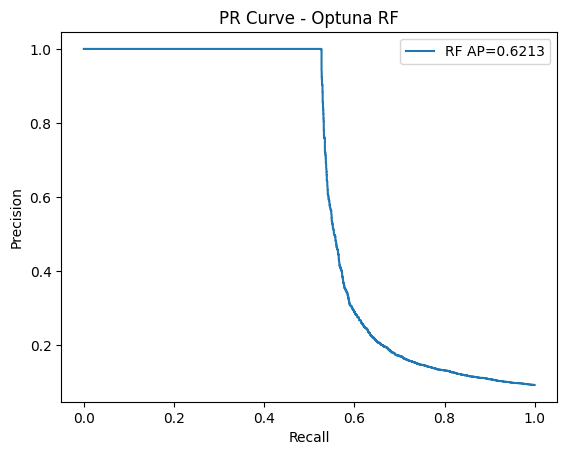

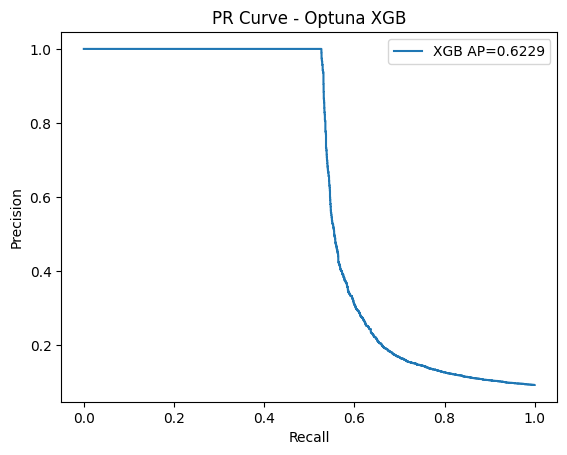

: 

In [ ]:
# Evaluate saved best pipelines on test set and plot PR curves
from sklearn.metrics import average_precision_score, precision_recall_curve

results_eval = {}

if os.path.exists('models/optuna_best_rf.pkl'):
    rf_pipe = joblib.load('models/optuna_best_rf.pkl')
    y_proba = rf_pipe.predict_proba(X_test)[:,1]
    ap = average_precision_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(recall, precision, label=f'RF AP={ap:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve - Optuna RF')
    plt.legend();
    plt.savefig(os.path.join(fig_dir, 'optuna_rf_pr.png'))
    results_eval['rf'] = {'ap': float(ap)}
    print('RF test AP:', ap)

if XGB_AVAILABLE and os.path.exists('models/optuna_best_xgb.pkl'):
    xgb_pipe = joblib.load('models/optuna_best_xgb.pkl')
    y_proba_xgb = xgb_pipe.predict_proba(X_test)[:,1]
    ap_xgb = average_precision_score(y_test, y_proba_xgb)
    precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
    plt.figure()
    plt.plot(recall, precision, label=f'XGB AP={ap_xgb:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve - Optuna XGB')
    plt.legend();
    plt.savefig(os.path.join(fig_dir, 'optuna_xgb_pr.png'))
    results_eval['xgb'] = {'ap': float(ap_xgb)}
    print('XGB test AP:', ap_xgb)

# Update results json with evals
if os.path.exists(results_json):
    with open(results_json) as fh:
        data = json.load(fh)
else:
    data = {}
data['eval_test'] = results_eval
with open(results_json, 'w') as fh:
    json.dump(data, fh, indent=2)
print('Saved evaluation results to', results_json)


In [ ]:
# Visualization utilities for Optuna (optimization history and importance)
try:
    import optuna.visualization.matplotlib as ovm
    def plot_study(study, fname):
        fig = ovm.plot_optimization_history(study)
        fig.savefig(fname)

    if 'study_rf' in globals():
        plot_study(study_rf, os.path.join(fig_dir, 'optuna_rf_history.png'))
    if XGB_AVAILABLE and 'study_xgb' in globals():
        plot_study(study_xgb, os.path.join(fig_dir, 'optuna_xgb_history.png'))
    print('Saved Optuna study figures to', fig_dir)
except Exception as e:
    print('Could not create optuna visualizations (optional):', e)

# Final note
print('Optuna tuning notebook finished. Adjust n_trials/time_budget for larger runs. Use storage_url for distributed experiments.')